# Predicting an RB's jump: who will beat his own track record next season?

Chase Brown went from 4.5 PPR points per game to 15.9 in 2024. Rachaad White, Isiah Pacheco and Chuba Hubbard all made similar leaps. Which signals were there the year before?

**Same method as the WR notebook** (`wr_jump_model.ipynb`), using the shared code in `jump_model.py`:
- **Baseline** = PPR points per game over this season and last, weighted by games played.
- **Change model** predicts next season's PPG minus that baseline (ridge regression).
- **Leap model** predicts the chance of a big leap: **+4 PPG over baseline and at least 14 PPG** (roughly RB2 territory).
- **Eligible:** 6+ games and 50+ touches (carries + targets).
- **Backtest:** each season from 2019 to 2024 is predicted using only earlier seasons. 2026 results are never used.

In [1]:
import sys
sys.path.append("..")                     # so we can import jump_model.py from the project folder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import jump_model as jm

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

POS = "RB"
cfg = jm.POSITIONS[POS]
FEATURES = cfg["features"]

df = pd.read_parquet("../data/processed/player_seasons.parquet")
d = jm.prepare(df, POS)
pool = d[cfg["eligible"](d)].copy()

lab = pool[(pool["season"] <= 2024) & (pool["next_games"] >= 6)].copy()
lab["ppg_change"] = lab["next_ppr_per_game"] - lab["baseline_ppg"]
lab["leap"] = ((lab["ppg_change"] >= cfg["leap_gain"]) & (lab["next_ppr_per_game"] >= cfg["leap_floor"])).astype(int)
print(f"{len(lab)} {POS} seasons | average change {lab['ppg_change'].mean():+.2f} PPG | "
      f"big leaps: {lab['leap'].sum()} ({lab['leap'].mean():.1%})")

535 RB seasons | average change -0.82 PPG | big leaps: 42 (7.9%)


## Regression to the mean

Players with a high baseline usually fall back the next year; players with a low one tend to rise. The model has to account for this before anything else.

In [2]:
lab["baseline_bucket"] = pd.cut(lab["baseline_ppg"], [0, 5, 8, 11, 14, 18, 40])
lab.groupby("baseline_bucket", observed=True).agg(
    players=("ppg_change", "size"), avg_change=("ppg_change", "mean"), leap_rate=("leap", "mean")).round(2)

,players,avg_change,leap_rate
baseline_bucket,,,
"(0, 5]",52,1.87,0.04
"(5, 8]",116,0.20,0.03
"(8, 11]",137,-0.87,0.12
"(11, 14]",93,-2.39,0.04
"(14, 18]",94,-1.05,0.12
"(18, 40]",43,-2.71,0.12


## The factors

| Group | Features |
|---|---|
| **Track record** | `baseline_ppg`, `ppr_per_game`, `second_half_trend` |
| **Workload** | `carries_per_game`, `targets_per_game`, `target_share`, `xfp_per_game` (expected points from usage), `tprr` |
| **Scoring role** | `rz_carry_share`, `gl_carry_share` (inside the 5) |
| **Runner skill and big plays** | `ryoe_per_carry` (yards over expected), `yac_per_carry` (after contact), `explosive_run_rate` (20+ yard runs), `run_10plus_rate` (10+ yard runs), `yac_per_reception`, `fp_over_expected_per_game` |
| **Career stage** | `age`, `years_exp`, `draft_pick_filled` |
| **Next season's opportunity** | `next_team_vacated_carry_share`, `next_team_vacated_target_share`, `next_preseason_depth_tier`, `depth_promotion`, `changed_team`, `lead_back_opening` (see below) |
| **Blocking and environment** | `team_run_stuff_rate`, `team_8plus_box_rate`, `team_epa_per_rush`, `qb_epa_per_dropback`, `team_pass_rate_over_exp`, `next_sos_rush_def_epa`, `games_missed` |

Missing values are filled with the median, and the model is told they were missing.

## Backtest: each season predicted using only earlier seasons

In [3]:
results = []
for season in range(2019, 2025):
    train, test = lab[lab["season"] < season], lab[lab["season"] == season]
    out = test[["name", "season", "team", "next_preseason_team", "age", "baseline_ppg",
                "next_ppr_per_game", "ppg_change", "leap", "next_preseason_rank"]].copy()
    out["pred_change"] = jm.change_model().fit(train[FEATURES], train["ppg_change"]).predict(test[FEATURES])
    out["leap_prob"] = jm.leap_model().fit(train[FEATURES], train["leap"]).predict_proba(test[FEATURES])[:, 1]
    results.append(out)
bt = pd.concat(results)
bt["pct"] = bt.groupby("season")["pred_change"].rank(pct=True)   # 1.00 = model's top predicted riser that season

naive = bt["ppg_change"].abs().mean()
model = (bt["ppg_change"] - bt["pred_change"]).abs().mean()
print(f"Average miss on next-season PPG: naive {naive:.2f} vs model {model:.2f}")
print(f"Correlation of predicted vs actual change: {np.corrcoef(bt['pred_change'], bt['ppg_change'])[0, 1]:.2f}")
print(f"Leap model AUC: {roc_auc_score(bt['leap'], bt['leap_prob']):.2f}  (0.5 = coin flip, 1.0 = perfect)")

Average miss on next-season PPG: naive 3.44 vs model 3.08
Correlation of predicted vs actual change: 0.40
Leap model AUC: 0.72  (0.5 = coin flip, 1.0 = perfect)


In [4]:
bt["decile"] = bt.groupby("season")["pred_change"].transform(
    lambda s: pd.qcut(s.rank(method="first"), 10, labels=False) + 1)
deciles = bt.groupby("decile").agg(predicted=("pred_change", "mean"), actual=("ppg_change", "mean"),
                                   leap_rate=("leap", "mean"), players=("leap", "size"))
deciles.round(2)

,predicted,actual,leap_rate,players
decile,,,,
1,-5.23,-3.91,0.00,39
2,-3.65,-2.98,0.06,35
3,-2.74,-1.81,0.06,36
4,-2.06,-1.43,0.09,34
5,-1.35,-1.40,0.00,38
6,-0.69,-0.91,0.06,35
7,-0.02,-0.46,0.06,34
8,0.69,1.05,0.08,36
9,1.39,1.00,0.20,35


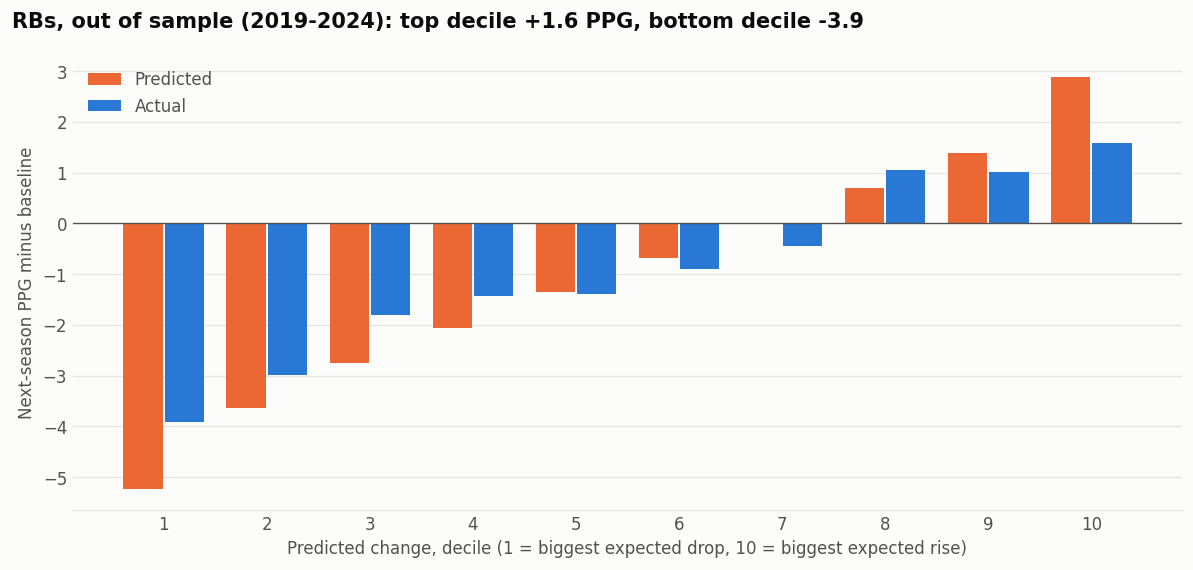

In [5]:
SURF, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e1"
BLUE, ORANGE, RED = "#2a78d6", "#eb6834", "#e34948"

def style(ax, fig):
    fig.patch.set_facecolor(SURF); ax.set_facecolor(SURF)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID); ax.tick_params(colors=INK2, length=0); ax.set_axisbelow(True)

top, bottom = deciles["actual"].iloc[-1], deciles["actual"].iloc[0]
fig, ax = plt.subplots(figsize=(10, 4.8), dpi=120); style(ax, fig)
x = np.arange(1, 11); w = 0.38
ax.bar(x - w/2 - 0.01, deciles["predicted"], w, color=ORANGE, label="Predicted")
ax.bar(x + w/2 + 0.01, deciles["actual"], w, color=BLUE, label="Actual")
ax.axhline(0, color=INK2, lw=0.8)
ax.set_xticks(x)
ax.set_xlabel("Predicted change, decile (1 = biggest expected drop, 10 = biggest expected rise)", color=INK2)
ax.set_ylabel("Next-season PPG minus baseline", color=INK2)
fig.suptitle(f"RBs, out of sample (2019-2024): top decile {top:+.1f} PPG, bottom decile {bottom:+.1f}",
             x=0.01, ha="left", color=INK, fontsize=12.5, fontweight="bold")
ax.legend(frameon=False, loc="upper left", labelcolor=INK2); ax.grid(axis="y", color=GRID)
plt.tight_layout(); plt.show()

## What drives a jump?

Weights from the change model trained on all 2016-2024 seasons. Features are standardized, so bars are comparable: each is the PPG change for a one-standard-deviation increase **with the other features held constant**. Features that move together (age and years of experience, for example) split credit between them, so read related bars as a group.

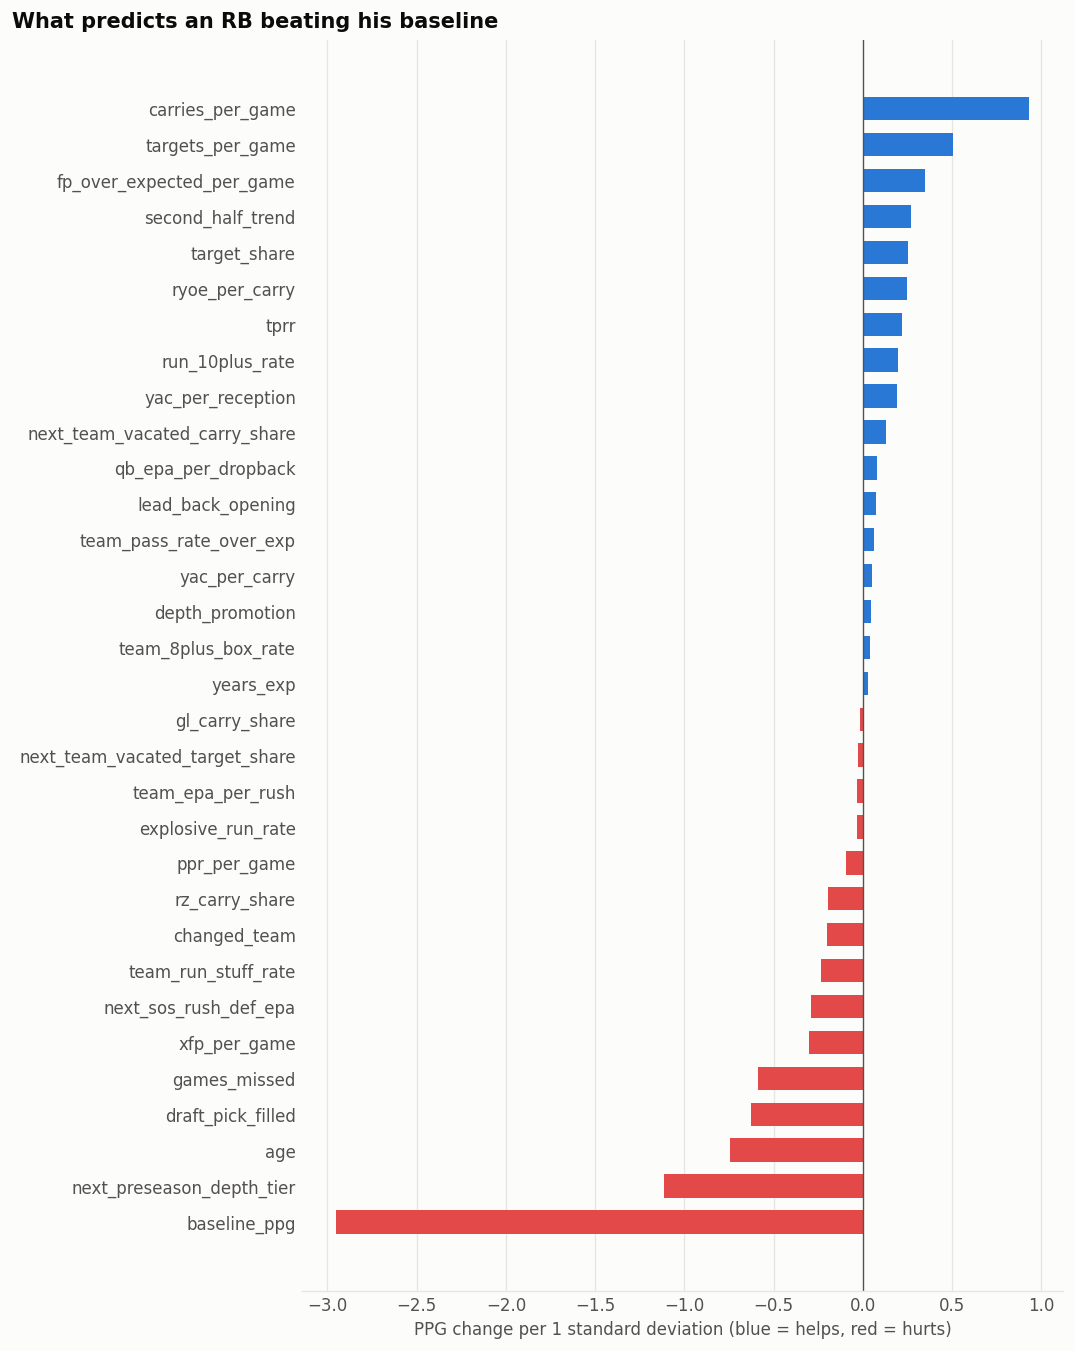

In [6]:
final_change = jm.change_model().fit(lab[FEATURES], lab["ppg_change"])
weights = pd.Series(final_change[-1].coef_[:len(FEATURES)], index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 0.32 * len(weights) + 1.2), dpi=120); style(ax, fig)
ax.barh(weights.index, weights.values, color=[BLUE if v > 0 else RED for v in weights.values], height=0.65)
ax.axvline(0, color=INK2, lw=0.8)
ax.set_xlabel("PPG change per 1 standard deviation (blue = helps, red = hurts)", color=INK2)
fig.suptitle("What predicts an RB beating his baseline", x=0.01, ha="left", color=INK, fontsize=12.5, fontweight="bold")
ax.grid(axis="x", color=GRID)
plt.tight_layout(); plt.show()

## The biggest jumps of 2019-2024: did the model see them coming?

`pct` = where the model ranked the player's predicted change among all eligible players that season (1.00 = top). Not cherry-picked: these are simply the largest actual gains.

In [7]:
cols = ["name", "season", "next_preseason_team", "age", "baseline_ppg", "next_ppr_per_game",
        "ppg_change", "pred_change", "pct", "leap_prob"]
bt.sort_values("ppg_change", ascending=False)[cols].head(12).round(2)

,name,season,next_preseason_team,age,baseline_ppg,next_ppr_per_game,ppg_change,pred_change,pct,leap_prob
1131,Chase Brown,2023,CIN,23.4,4.46,15.94,11.48,3.22,0.95,0.12
652,Cordarrelle Patterson,2020,ATL,29.5,3.28,14.66,11.38,-0.06,0.79,0.00
1277,Kenny Gainwell,2024,PIT,25.5,4.85,13.02,8.17,-1.65,0.36,0.01
935,Raheem Mostert,2022,MIA,30.4,10.02,17.85,7.83,-1.65,0.40,0.00
946,Rachaad White,2022,TB,23.6,8.30,15.76,7.46,3.58,0.98,0.10
947,Isiah Pacheco,2022,KC,23.5,7.94,15.28,7.34,2.48,0.90,0.05
1095,Chuba Hubbard,2023,CAR,24.2,8.78,16.11,7.33,1.89,0.87,0.16
1118,Rico Dowdle,2023,DAL,25.2,5.08,12.36,7.28,0.26,0.62,0.02
497,J.D. McKissic,2019,WAS,26.0,4.70,11.96,7.26,1.08,0.81,0.04
624,Darrell Henderson,2020,LA,23.0,6.36,13.62,7.25,5.48,1.00,0.21


## Case studies

In [8]:
bt[bt["name"].isin(['Chase Brown', 'Rachaad White', 'Isiah Pacheco', 'Raheem Mostert'])][cols].sort_values(["name", "season"]).round(2)

,name,season,next_preseason_team,age,baseline_ppg,next_ppr_per_game,ppg_change,pred_change,pct,leap_prob
1131,Chase Brown,2023,CIN,23.4,4.46,15.94,11.48,3.22,0.95,0.12
1226,Chase Brown,2024,CIN,24.4,11.02,16.62,5.61,1.77,0.96,0.16
947,Isiah Pacheco,2022,KC,23.5,7.94,15.28,7.34,2.48,0.90,0.05
1083,Isiah Pacheco,2023,KC,24.5,11.25,8.13,-3.13,-0.14,0.57,0.10
1279,Isiah Pacheco,2024,KC,25.5,12.90,6.72,-6.18,-4.27,0.07,0.01
946,Rachaad White,2022,TB,23.6,8.30,15.76,7.46,3.58,0.98,0.10
1072,Rachaad White,2023,TB,24.6,12.03,13.31,1.28,1.16,0.78,0.28
1238,Rachaad White,2024,TB,25.6,14.61,8.41,-6.20,-2.37,0.22,0.05
467,Raheem Mostert,2019,SF,27.4,8.57,12.46,3.89,-0.85,0.52,0.01
935,Raheem Mostert,2022,MIA,30.4,10.02,17.85,7.83,-1.65,0.40,0.00


## Backfield openings: the Kenneth Walker case

In 2025 Walker split Seattle's backfield with Zach Charbonnet (about 47% of Seattle's carries).
For 2026 he moved to Kansas City as the clear RB1, where the backs who returned had only about 17% of
the 2025 carries. Does that situation predict a jump?

`lead_back_opening` flags it: he shared his backfield (under 55% of team carries), he's first on his next
team's preseason depth chart, and returning teammates there had under 25% of its carries.

In [9]:
lab["situation"] = np.select(
    [lab["lead_back_opening"] == 1, lab["next_preseason_depth_tier"] == 1],
    ["Lead back, shared before, little competition", "Lead back, other situations"], "Not the lead back")
lab.groupby("situation").agg(players=("ppg_change", "size"), avg_baseline=("baseline_ppg", "mean"),
                             avg_change=("ppg_change", "mean"), leap_rate=("leap", "mean")).round(2)

,players,avg_baseline,avg_change,leap_rate
situation,,,,
"Lead back, other situations",187,14.68,-0.88,0.13
"Lead back, shared before, little competition",62,10.94,1.26,0.15
Not the lead back,286,8.09,-1.22,0.03


Backs in Walker's situation gained about +1.3 PPG on average while other lead backs lost about 1 PPG.
But much of that is already captured by other factors (they tend to have lower baselines and a starter
role), so adding the flag barely changes the backtest. The model now nudges Walker up rather than down,
but his 2026 start (27.5 PPG through Week 4, vs. a 13.3 baseline) is far beyond anything the history supports.
That's the honest limit of the model: it can see that the opportunity grew, not how dominant he'd be with it.

In [10]:
w = now_preview = pool[(pool["season"] == 2025) & (pool["name"] == "Kenneth Walker III")]
w[["name", "team", "next_preseason_team", "team_carry_share", "next_competition_carry_share",
   "lead_back_opening", "baseline_ppg"]].round(2)

,name,team,next_preseason_team,team_carry_share,next_competition_carry_share,lead_back_opening,baseline_ppg
1386,Kenneth Walker III,SEA,KC,0.47,0.17,1.0,13.32


## 2026 predictions

Both models retrained on every labeled season (2016-2024), then applied to 2025 seasons. `next_preseason_rank` is the FantasyPros consensus positional rank before the 2026 season.

In [11]:
final_leap = jm.leap_model().fit(lab[FEATURES], lab["leap"])
now = pool[pool["season"] == 2025].copy()
now["pred_change_2026"] = final_change.predict(now[FEATURES])
now["pred_ppg_2026"] = now["baseline_ppg"] + now["pred_change_2026"]
now["leap_prob_2026"] = final_leap.predict_proba(now[FEATURES])[:, 1]
show = ["name", "next_preseason_team", "age", "baseline_ppg", "pred_ppg_2026", "pred_change_2026",
        "leap_prob_2026", "next_preseason_rank"]

# Most likely to make a big leap
now.sort_values("leap_prob_2026", ascending=False)[show].head(12).round(2)

,name,next_preseason_team,age,baseline_ppg,pred_ppg_2026,pred_change_2026,leap_prob_2026,next_preseason_rank
1366,Bijan Robinson,ATL,23.6,20.96,20.16,-0.80,0.43,2.0
1375,Ashton Jeanty,LV,21.7,14.42,14.72,0.31,0.35,11.0
1371,Chase Brown,CIN,25.4,16.29,15.37,-0.92,0.18,6.0
1386,Kenneth Walker III,KC,24.9,13.32,13.75,0.43,0.15,10.0
1380,Kenny Gainwell,TB,26.5,8.35,9.53,1.18,0.15,32.0
1379,D'Andre Swift,CHI,26.6,13.43,13.55,0.12,0.13,18.0
1404,Blake Corum,LA,24.8,4.87,7.92,3.05,0.13,36.0
1383,Breece Hall,NYJ,24.3,14.02,13.98,-0.04,0.13,13.0
1399,Omarion Hampton,LAC,22.5,15.08,13.60,-1.47,0.13,9.0
1376,Javonte Williams,DAL,25.4,12.14,12.26,0.11,0.12,16.0


In [12]:
# Biggest predicted risers among players who already have a real role (baseline 9+ PPG)
now[now["baseline_ppg"] >= 9].sort_values("pred_change_2026", ascending=False)[show].head(10).round(2)

,name,next_preseason_team,age,baseline_ppg,pred_ppg_2026,pred_change_2026,leap_prob_2026,next_preseason_rank
1374,Travis Etienne,NO,26.6,12.00,12.47,0.47,0.10,17.0
1386,Kenneth Walker III,KC,24.9,13.32,13.75,0.43,0.15,10.0
1385,TreVeyon Henderson,NE,22.9,12.13,12.45,0.32,0.11,25.0
1390,Quinshon Judkins,CLE,21.8,12.13,12.44,0.31,0.11,22.0
1375,Ashton Jeanty,LV,21.7,14.42,14.72,0.31,0.35,11.0
1379,D'Andre Swift,CHI,26.6,13.43,13.55,0.12,0.13,18.0
1376,Javonte Williams,DAL,25.4,12.14,12.26,0.11,0.12,16.0
1381,Jaylen Warren,PIT,26.8,11.01,11.09,0.09,0.10,27.0
1383,Breece Hall,NYJ,24.3,14.02,13.98,-0.04,0.13,13.0
1389,Rhamondre Stevenson,NE,27.5,12.23,12.02,-0.21,0.12,26.0


In [13]:
# Potential bargains: ranked outside the top 24 RBs, sorted by predicted 2026 PPG
now[now["next_preseason_rank"] > 24].sort_values("pred_ppg_2026", ascending=False)[show].head(10).round(2)

,name,next_preseason_team,age,baseline_ppg,pred_ppg_2026,pred_change_2026,leap_prob_2026,next_preseason_rank
1385,TreVeyon Henderson,NE,22.9,12.13,12.45,0.32,0.11,25.0
1389,Rhamondre Stevenson,NE,27.5,12.23,12.02,-0.21,0.12,26.0
1407,J.K. Dobbins,DEN,26.7,13.38,11.65,-1.73,0.04,34.0
1402,Chuba Hubbard,CAR,26.2,12.23,11.26,-0.97,0.05,33.0
1381,Jaylen Warren,PIT,26.8,11.01,11.09,0.09,0.10,27.0
1387,Tony Pollard,TEN,28.3,11.71,11.04,-0.68,0.03,28.0
1384,RJ Harvey,DEN,24.6,12.15,10.82,-1.33,0.06,31.0
1392,Tyrone Tracy Jr.,NYG,25.8,10.72,9.82,-0.91,0.05,54.0
1382,Rico Dowdle,PIT,27.2,12.55,9.53,-3.02,0.01,29.0
1380,Kenny Gainwell,TB,26.5,8.35,9.53,1.18,0.15,32.0


### Early 2026 check

If `grade_2026.py` has been run, this compares the predictions with 2026 results so far. A few games is mostly noise, so treat this as a progress report, not a verdict.

In [14]:
from pathlib import Path
grades_path = Path("../predictions/2026_grades.csv")
if grades_path.exists():
    g = pd.read_csv(grades_path)
    g = g[(g["position"] == POS) & (g["games_2026"] >= 2)]
    print(f"Through week {int(g['through_week'].max())}: {len(g)} RBs with 2+ games")
    display(g.sort_values("leap_prob_2026", ascending=False)[
        ["name", "baseline_ppg", "pred_ppg_2026", "leap_prob_2026", "games_2026", "ppg_2026"]].head(12).round(2))
else:
    print("Run grade_2026.py first to see 2026 results.")

Through week 4: 57 RBs with 2+ games


,name,baseline_ppg,pred_ppg_2026,leap_prob_2026,games_2026,ppg_2026
15,Ashton Jeanty,14.42,14.63,0.35,4.0,18.48
0,Bijan Robinson,20.96,20.06,0.34,4.0,26.35
12,Chase Brown,16.29,15.51,0.22,4.0,14.50
121,Blake Corum,4.87,7.88,0.20,4.0,5.55
40,TreVeyon Henderson,12.13,12.64,0.15,3.0,7.23
92,Kenny Gainwell,8.35,9.46,0.15,4.0,5.25
1,Jahmyr Gibbs,21.46,19.63,0.14,4.0,29.00
42,Javonte Williams,12.14,12.47,0.14,4.0,20.45
5,De'Von Achane,18.87,18.13,0.14,3.0,8.20
44,Rhamondre Stevenson,12.23,12.38,0.13,4.0,10.82


## Takeaways

1. **RB is an opportunity position.** Holding everything else equal, the biggest positive driver is **carries per game**, and the biggest negatives (after the baseline) are being lower on next year's **depth chart** and **age**. Draft capital matters too: teams keep feeding backs they invested in.
2. **Receiving work matters.** Targets per game and target share both push predictions up: pass-catching backs have more ways to score in PPR.
3. **Skill shows up, but smaller.** Rush yards over expected and points over expected help, though less than workload.
4. **Leaps happen at every level.** About 40% of RB leaps came from backs who already had a 14+ PPG baseline: one injury or departure ahead of them can double a back's workload.
5. **Hits and misses:** Chase Brown's 2024 leap *was* flagged (top 5% of predicted risers), and so were Rachaad White and Isiah Pacheco in 2023, though the model expected much smaller jumps. Raheem Mostert's 2023 season at age 31 was missed, and Cordarrelle Patterson's 2021 move to Atlanta was flagged as a riser (top 21%) but nowhere near his actual +11 PPG.

**Caveats:** small samples (a few dozen leaps per position), linear models that can't capture every interaction, and no coaching data yet.